In [13]:
import dipy.reconst.dti as dti
import numpy as np

import matplotlib.pyplot as plt

In [15]:
from dipy.data import get_fnames

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames('stanford_hardi')

In [31]:
from dipy.io.image import load_nifti
from dipy.io.gradients import read_bvals_bvecs

data, affine = load_nifti(hardi_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)


np.save("bvecs.npy", bvecs)
np.save("bvals.npy", bvals)

In [32]:
from dipy.core.gradients import gradient_table
gtab = gradient_table(bvals, bvecs)

In [33]:
print("b-value = {} s/mm^2".format(gtab.bvals))
print("b-vectors = {} ".format(gtab.bvecs))

b-value = [   0.    0.    0.    0.    0.    0.    0.    0.    0.    0. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000.] s/mm^2
b-vector

In [34]:
from dipy.segment.mask import median_otsu

maskdata, mask = median_otsu(
    data, vol_idx=range(10, 50), median_radius=3, numpass=1, autocrop=True, dilate=2
)
print(f"maskdata.shape {maskdata.shape}")

maskdata.shape (71, 88, 62, 160)


In [36]:
np.save("masked_data",maskdata)

In [ ]:
tenmodel = dti.TensorModel(gtab)

: 

In [27]:
tenfit = tenmodel.fit(maskdata)

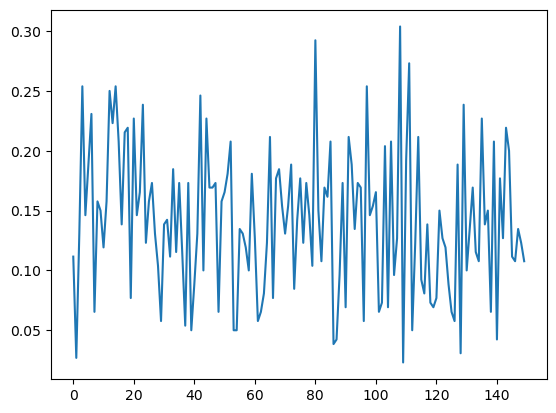

In [22]:
_ = plt.plot(train_data[40,53,20,:])

In [23]:
dti_model = dti.TensorModel(gtab_train)

In [24]:
dti_fit = dti_model.fit(train_data)

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (7,160)->(7,160) (10000,150)->(10000,newaxis,150) 

In [132]:
dti_fit.model_params.shape

(81, 106, 76, 12)

In [17]:
predict = S0[...,None]*dti_fit.predict(gtab_test, S0=1)

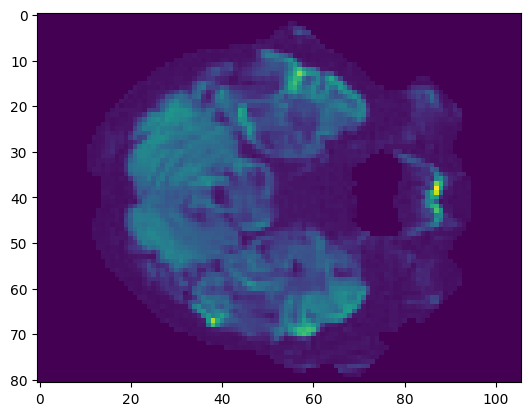

In [18]:
plt.imshow(predict[:,:,20,0])
plt.show()

In [26]:
train_data.shape

(81, 106, 76, 150)

In [ ]:
pixel = train_data[50:51,50:51,50:51, :]


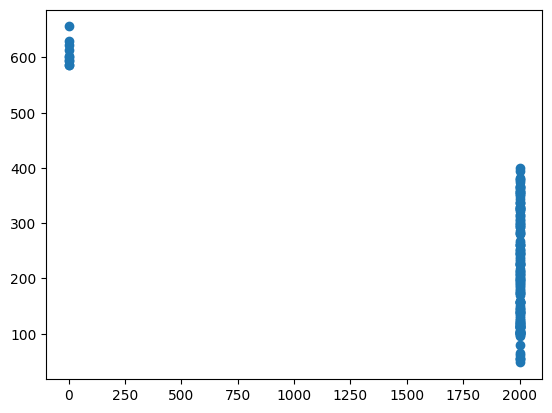

In [32]:
plt.plot(gtab_train.bvals, pixel[0,0,0,:], 'o')
plt.show()